# Random Forest Regression for Continuous Stock Return Prediction

This notebook completes the **continuous prediction** part of the coursework. We use firm fundamentals from year *t* to predict the realised stock return in year *t+1*.

## What This Notebook Does

Each section is commented so the logic is easy to follow:

- load the cleaned pooled dataset
- clarify the difference between **feature year** and **realised return year**
- inspect the target distribution and check whether the year-to-year gaps are reasonable
- tune a Random Forest using an expanding-window time split
- fit the final regression model and compare it with a mean baseline
- visualise prediction quality and feature importance
- explain why out-of-sample regression is difficult for this dataset

In [2]:
# Core libraries for data handling and plotting.
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools used for the regression pipeline.
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
RANDOM_STATE = 42

## 1. Load The Data And Define The Split

The most important clarification is the meaning of `Year` in this dataset.

- `Year` = the **financial-feature year**
- `Stock_Return` = the **next year's realised return**

So a row with `Year = 2014` contains 2014 accounting features paired with the return realised in **2015**. To make this explicit, we create a new column called `Return_Realized_Year = Year + 1`.

In [ ]:
# Read the cleaned combined dataset used for the coursework.
data_path = 'cleaned_dataset.csv'
df = pd.read_csv(data_path)

# The target is the continuous next-year return.
target_col = 'Stock_Return'

# Add an explicit realised-return year so the later summary tables are not misleading.
df['Return_Realized_Year'] = df['Year'] + 1

# Remove identifiers, labels, and time markers from the feature matrix.
drop_cols = ['Ticker', 'Sector', 'Stock_Return', 'Class', 'Year', 'Return_Direction', 'Return_Realized_Year']
feature_cols = [col for col in df.columns if col not in drop_cols]

# Time-aware split: train on 2014-2017 features, test on 2018 features.
# In return terms this means training on 2015-2018 realised returns and testing on 2019 realised returns.
train_df = df[df['Year'] < 2018].copy()
test_df = df[df['Year'] == 2018].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f'Total observations: {len(df):,}')
print(f'Number of features used: {len(feature_cols)}')
print(f'Training rows (feature years 2014-2017): {len(train_df):,}')
print(f'Test rows (feature year 2018): {len(test_df):,}')
print(f'Missing values in selected features: {df[feature_cols].isna().sum().sum():,}')
print()
print('Important note:')
print('`Year` is the accounting-feature year, while `Return_Realized_Year` is the year when the target return happens.')

FileNotFoundError: [Errno 2] No such file or directory: 'cleaned_dataset.csv'

## 2. Sanity Check The Target Distribution

This section directly addresses the large gap in the year summary.

We show three views:

- summary by **feature year**
- summary by **realised return year**
- summary of the **training vs test** target distribution

If the gaps are still large after relabelling, that indicates genuine market regime differences rather than a coding mistake.

In [ ]:
# Summary indexed by feature year. This is the version that can look confusing at first glance.
feature_year_summary = df.groupby('Year')[target_col].agg(['count', 'mean', 'median', 'std']).round(3)

# Summary indexed by realised return year. This is the more intuitive interpretation of the target.
realized_year_summary = df.groupby('Return_Realized_Year')[target_col].agg(['count', 'mean', 'median', 'std']).round(3)

# Compare the target distribution seen in training with the held-out test period.
split_summary = pd.DataFrame({
    'Train (feature years 2014-2017, returns 2015-2018)': train_df[target_col].agg(['count', 'mean', 'median', 'std']),
    'Test (feature year 2018, returns 2019)': test_df[target_col].agg(['count', 'mean', 'median', 'std']),
}).T.round(3)

print('Summary by feature year:')
display(feature_year_summary)

print('Summary by realised return year:')
display(realized_year_summary)

print('Train-test target shift:')
display(split_summary)

Summary by feature year:


,count,mean,median,std
Year,,,,
2014,3787,-5.001,-5.514,43.156
2015,4114,20.475,17.260,54.212
2016,4783,17.557,10.811,55.226
2017,4957,-13.463,-13.364,40.849
2018,4390,19.665,17.589,57.304


Summary by realised return year:


,count,mean,median,std
Return_Realized_Year,,,,
2015,3787,-5.001,-5.514,43.156
2016,4114,20.475,17.260,54.212
2017,4783,17.557,10.811,55.226
2018,4957,-13.463,-13.364,40.849
2019,4390,19.665,17.589,57.304


Train-test target shift:


,count,mean,median,std
"Train (feature years 2014-2017, returns 2015-2018)",17641.0,4.679,0.981,50.954
"Test (feature year 2018, returns 2019)",4390.0,19.665,17.589,57.304


### Why The Gap Looks Large

The gap is real, but the first table can make it look more confusing than it is.

- The row labelled `2014` is really about **2015 realised returns**.
- The row labelled `2017` is really about **2018 realised returns**.
- The test set (`Year = 2018`) corresponds to **2019 realised returns**, which are much stronger on average than the training years.

That last point matters a lot: the training target mean is much lower than the test target mean, so the model is being asked to generalise from a weaker return environment to a much stronger one. This distribution shift is one reason the regression task is hard and the final $R^2$ is weak.

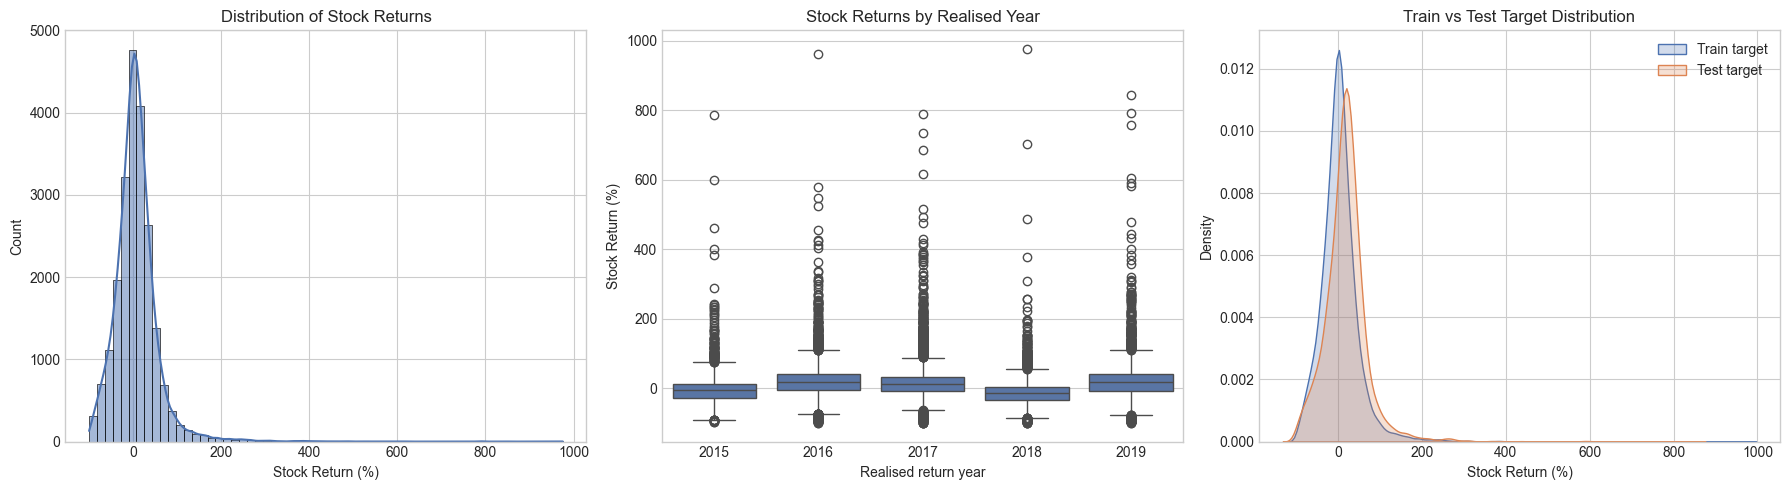

In [ ]:
# Plot 1: overall return distribution.
# Plot 2: boxplots by realised return year, which is the clearer time interpretation.
# Plot 3: KDE comparison between train and test target distributions.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df[target_col], bins=60, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Stock Returns')
axes[0].set_xlabel('Stock Return (%)')

sns.boxplot(data=df, x='Return_Realized_Year', y=target_col, ax=axes[1])
axes[1].set_title('Stock Returns by Realised Year')
axes[1].set_xlabel('Realised return year')
axes[1].set_ylabel('Stock Return (%)')

sns.kdeplot(train_df[target_col], fill=True, label='Train target', ax=axes[2])
sns.kdeplot(test_df[target_col], fill=True, label='Test target', ax=axes[2])
axes[2].set_title('Train vs Test Target Distribution')
axes[2].set_xlabel('Stock Return (%)')
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Hyperparameter Tuning With Expanding-Window Validation

To stay consistent with the coursework write-up, the forest is tuned using a **time-aware** validation scheme:

- train on 2014, validate on 2015
- train on 2014-2015, validate on 2016
- train on 2014-2016, validate on 2017

This avoids using future data when selecting hyperparameters.

To keep the runtime manageable, this notebook uses a **reduced grid search** rather than a very large full search:
- `n_estimators`: `100`, `300`
- `max_depth`: `5`, `10`, `None`
- `min_samples_split`: `2`, `5`, `10`

This keeps the same time-aware validation logic while making the tuning section much more practical to run.

In [ ]:
# Reduced grid search for a practical runtime on this dataset.
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
}

# Build expanding-window folds as index arrays.
# Fold 0: train on 2014, validate on 2015
# Fold 1: train on 2014-2015, validate on 2016
# Fold 2: train on 2014-2016, validate on 2017
years = train_df['Year'].values
expanding_cv = [
    (np.where(years <= 2014)[0], np.where(years == 2015)[0]),
    (np.where(years <= 2015)[0], np.where(years == 2016)[0]),
    (np.where(years <= 2016)[0], np.where(years == 2017)[0]),
]

grid_search = GridSearchCV(
    RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    param_grid,
    cv=expanding_cv,
    scoring='neg_root_mean_squared_error',
    refit=False,
    verbose=1,
)
grid_search.fit(X_train, y_train)

# Display top 10 results.
cv_results = pd.DataFrame(grid_search.cv_results_).sort_values('rank_test_score')
display_cols = [
    'param_n_estimators', 'param_max_depth', 'param_min_samples_split',
    'mean_test_score', 'std_test_score', 'rank_test_score',
]
cv_top = cv_results[display_cols].head(10).copy()
cv_top['cv_rmse'] = -cv_top['mean_test_score']
cv_top = cv_top.drop(columns=['mean_test_score']).rename(columns={'std_test_score': 'cv_rmse_std'})
print('Top 10 configurations by CV RMSE:')
display(cv_top)

best_params = grid_search.best_params_.copy()
print(f'\nBest configuration: {best_params}')
print(f'Best CV RMSE: {-grid_search.best_score_:.3f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits


## 4. Fit The Final Model And Evaluate It

The final model is trained on all training rows using the best validation configuration.

We compare it against a simple **mean baseline**. If Random Forest cannot beat the baseline by much, that does not mean the code is wrong; it means the signal for **exact return magnitude** is weak relative to the amount of noise in the target.

In [ ]:
# Train the final random forest regressor using the best parameters from the reduced grid search.
rf_reg = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params,
)
rf_reg.fit(X_train, y_train)

# Generate predictions for the held-out 2018 feature-year test set.
rf_preds = rf_reg.predict(X_test)

# Baseline: always predict the mean return from the training target.
baseline_preds = np.full_like(y_test, y_train.mean(), dtype=float)

results_table = pd.DataFrame([
    {
        'Model': 'Mean baseline',
        'RMSE': np.sqrt(mean_squared_error(y_test, baseline_preds)),
        'R2': r2_score(y_test, baseline_preds),
    },
    {
        'Model': 'Random Forest Regressor',
        'RMSE': np.sqrt(mean_squared_error(y_test, rf_preds)),
        'R2': r2_score(y_test, rf_preds),
    },
]).round(4)
display(results_table)

# Show how different the average test target is from what the model saw in training.
print(f'Training target mean: {y_train.mean():.3f}')
print(f'Test target mean: {y_test.mean():.3f}')
print(f'Average random forest prediction: {rf_preds.mean():.3f}')

# Store predictions for plotting and error analysis.
prediction_frame = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': rf_preds,
    'Residual': y_test.values - rf_preds,
})
prediction_frame.head()

,Model,RMSE,R2
0,Mean baseline,59.2247,-0.0684
1,Random Forest Regressor,58.8391,-0.0545


Training target mean: 4.679
Test target mean: 19.665
Average random forest prediction: 7.612


,Actual,Predicted,Residual
0,32.794573,8.483635,24.310939
1,40.588068,2.673301,37.914767
2,30.295514,3.332911,26.962603
3,64.213737,2.061773,62.151964
4,44.757840,11.690313,33.067527


## 5. Stock-Level Comparison Table

To make the regression results more intuitive, the table below compares the **predicted return** and the **actual realised return** for each stock in the held-out `Year = 2018` test set.

The columns are:

- `Ticker`: stock identifier
- `Feature_Year`: the accounting-feature year used for prediction
- `Return_Realized_Year`: the year in which the actual return happened
- `Actual_Return`: observed stock return
- `Predicted_Return`: Random Forest prediction
- `Residual`: actual minus predicted
- `Absolute_Error`: size of the prediction error

The table is sorted by `Ticker` so it is easier to look up individual stocks.

In [ ]:
# Build a stock-level comparison table for every company in the 2018 feature-year test set.
comparison_table = test_df[['Ticker', 'Year', 'Return_Realized_Year']].copy()
comparison_table = comparison_table.rename(columns={'Year': 'Feature_Year'})
comparison_table['Actual_Return'] = y_test.values
comparison_table['Predicted_Return'] = rf_preds
comparison_table['Residual'] = comparison_table['Actual_Return'] - comparison_table['Predicted_Return']
comparison_table['Absolute_Error'] = comparison_table['Residual'].abs()

# Sort alphabetically for easier stock-by-stock inspection.
comparison_table = comparison_table.sort_values('Ticker').reset_index(drop=True)

# Round numeric columns for cleaner notebook output.
comparison_table[['Actual_Return', 'Predicted_Return', 'Residual', 'Absolute_Error']] = (
    comparison_table[['Actual_Return', 'Predicted_Return', 'Residual', 'Absolute_Error']].round(4)
)

print(f'Full stock-level comparison table rows: {len(comparison_table):,}')
display(comparison_table)

Full stock-level comparison table rows: 4,390


,Ticker,Feature_Year,Return_Realized_Year,Actual_Return,Predicted_Return,Residual,Absolute_Error
0,A,2018,2019,30.9761,8.4947,22.4814,22.4814
1,AA,2018,2019,-18.0259,8.6693,-26.6952,26.6952
2,AABA,2018,2019,25.2575,18.9257,6.3319,6.3319
3,AAL,2018,2019,-10.6021,8.4016,-19.0037,19.0037
4,AAMC,2018,2019,-58.8471,-2.5940,-56.2530,56.2530
...,...,...,...,...,...,...,...
4385,ZTR,2018,2019,42.5715,9.7289,32.8427,32.8427
4386,ZTS,2018,2019,57.6627,9.4129,48.2498,48.2498
4387,ZUMZ,2018,2019,76.0448,5.7296,70.3152,70.3152
4388,ZYME,2018,2019,209.4622,11.5474,197.9148,197.9148


## 6. Diagnostic Plots

These plots help explain the model behaviour:

- **Actual vs Predicted** shows whether points lie near the 45-degree line.
- **Residual distribution** shows whether the model systematically under- or over-predicts.

Because the test set has a much stronger return environment than the training set, the model tends to predict values closer to the middle of the historical range than the true realised returns.

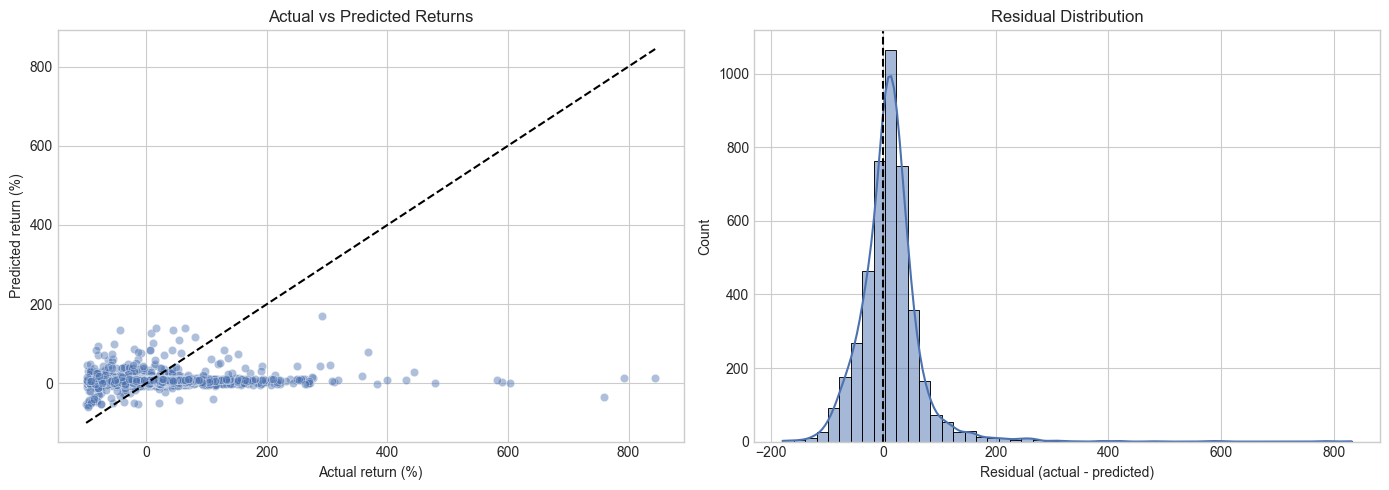

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=prediction_frame, x='Actual', y='Predicted', alpha=0.45, ax=axes[0])
min_val = min(prediction_frame['Actual'].min(), prediction_frame['Predicted'].min())
max_val = max(prediction_frame['Actual'].max(), prediction_frame['Predicted'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], linestyle='--', color='black')
axes[0].set_title('Actual vs Predicted Returns')
axes[0].set_xlabel('Actual return (%)')
axes[0].set_ylabel('Predicted return (%)')

sns.histplot(prediction_frame['Residual'], bins=50, kde=True, ax=axes[1])
axes[1].axvline(0, linestyle='--', color='black')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (actual - predicted)')

plt.tight_layout()
plt.show()

## 7. Feature Importance

Even when exact return prediction is difficult, the forest still tells us which features matter most for its splits. This is useful for the discussion section because it highlights which accounting variables carry the strongest predictive signal in the model.

,importance
EPS Diluted,0.064930
priceToBookRatio,0.063763
Earnings Yield,0.062385
freeCashFlowOperatingCashFlowRatio,0.061384
Weighted Average Shs Out,0.035391
Weighted Average Shs Out (Dil),0.030290
Operating Cash Flow per Share,0.026538
5Y Revenue Growth (per Share),0.025239
Investment purchases and sales,0.022661
PTB ratio,0.022298


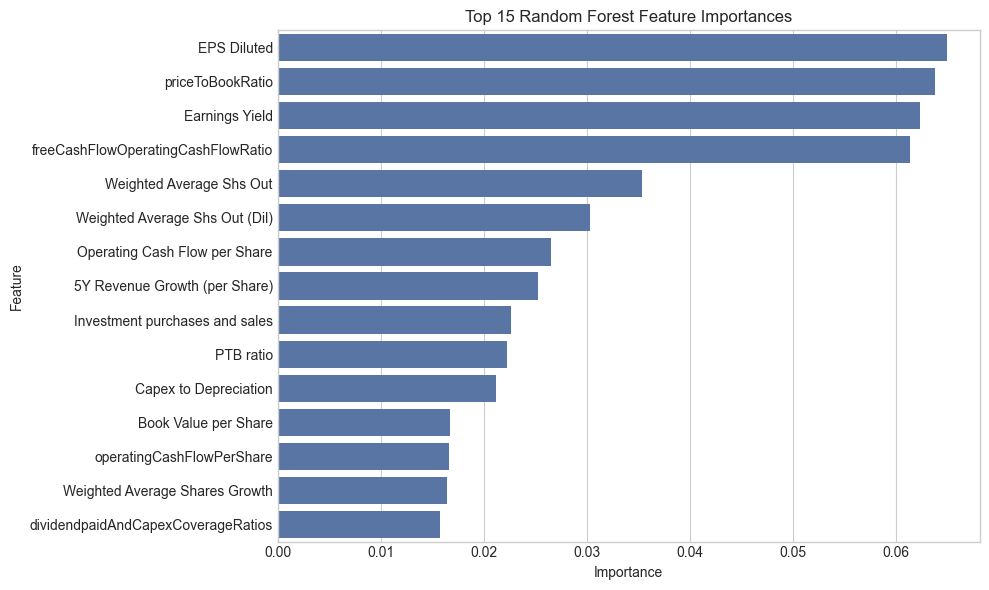

In [ ]:
# Impurity-based feature importance from the trained forest.
feature_importance = pd.Series(rf_reg.feature_importances_, index=feature_cols).sort_values(ascending=False)
top_features = feature_importance.head(15)
display(top_features.to_frame('importance'))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, orient='h')
plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 8. Written Interpretation For The Report

This part implemented a full Random Forest regression pipeline for **continuous stock return prediction**. The cleaned pooled dataset was loaded, the year label was clarified by distinguishing between **feature year** and **realised return year**, and the target distribution was checked before modelling. A time-aware expanding-window validation scheme was then used to tune the Random Forest. To keep the runtime manageable, the tuning stage used a reduced grid search over `n_estimators = [100, 300]`, `max_depth = [5, 10, None]`, and `min_samples_split = [2, 5, 10]`. The final model was then trained using the best parameter combination from that search and evaluated on the held-out 2018 feature-year sample, corresponding to 2019 realised returns.

The year summary initially appeared to have very large jumps, but this was not caused by a coding error. The apparent gap is mainly due to the dataset construction: each year of accounting features is paired with the following year's return. Once the return years are labelled correctly, the pattern is easier to interpret. The test period also has a substantially higher average return than the training period, which creates a clear distribution shift. This helps explain why the Random Forest only slightly improves on the mean baseline and still produces a weak out-of-sample $R^2$: the model is trying to predict exact return magnitude in a noisy, regime-dependent financial setting.

Overall, this section shows that Random Forest can identify useful non-linear structure and highlight influential variables such as EPS-related measures, earnings yield, and cash-flow-based ratios. However, the results also confirm that predicting the exact size of future stock returns is much harder than predicting only the direction of returns.